<a href="https://colab.research.google.com/github/AjanyaVinayan/ML-LAB-2547205/blob/CIA---3---HEART-DISEASE/CIA3_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Heart Disease Risk Prediction Using Ensemble Machine Learning

### Machine Learning CIA Project

**Dataset:** UCI Heart Disease – Cleveland Dataset

**Problem Type:** Supervised Binary Classification

In [ ]:
# ============================================
# IMPORT REQUIRED LIBRARIES
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Model saving
import joblib

# Display
from IPython.display import display

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ============================================
# UPLOAD DATASET
# ============================================

from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving processed.cleveland.data to processed.cleveland (1).data
Uploaded files:
processed.cleveland (1).data


In [ ]:
# ============================================
# LOAD UCI CLEVELAND HEART DISEASE DATASET
# ============================================

file_name = "processed.cleveland.data"

column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(
    file_name,
    header=None,
    names=column_names,
    na_values="?"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
# ============================================
# BASIC DATA INSPECTION
# ============================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Number of rows: 303
Number of columns: 14

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    floa

In [ ]:
# ============================================
# STATISTICAL SUMMARY
# ============================================

display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [ ]:
# ============================================
# MISSING VALUE ANALYSIS
# ============================================

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

display(missing_table)

,Missing Values,Percentage
age,0,0.000000
sex,0,0.000000
cp,0,0.000000
trestbps,0,0.000000
chol,0,0.000000
fbs,0,0.000000
restecg,0,0.000000
thalach,0,0.000000
exang,0,0.000000
oldpeak,0,0.000000


In [ ]:
# ============================================
# DUPLICATE ANALYSIS
# ============================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated()])
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


The `ca` (number of major vessels) and `thal` (thalassemia type) columns have a small number of missing values. Since these are categorical or ordinal in nature (even though stored as float), imputing them with the mode (most frequent value) is a reasonable strategy. This preserves the distribution of the existing categories as much as possible.

In [ ]:
# ============================================
# IMPUTE MISSING VALUES WITH MODE
# ============================================

# Impute 'ca' with its mode
ca_mode = df['ca'].mode()[0]
df['ca'].fillna(ca_mode, inplace=True)

# Impute 'thal' with its mode
thal_mode = df['thal'].mode()[0]
df['thal'].fillna(thal_mode, inplace=True)

print("Missing values in 'ca' and 'thal' imputed with their respective modes.")

# Verify no more missing values in these columns
print("\nMissing values after imputation:")
display(df[['ca', 'thal']].isnull().sum().to_frame(name='Missing Values'))

Missing values in 'ca' and 'thal' imputed with their respective modes.

Missing values after imputation:


,Missing Values
ca,0
thal,0


The original UCI target contains five values:

- 0 = absence of heart disease
- 1–4 = presence of heart disease

Since this project focuses on binary classification, the target is converted into:

- 0 = No heart disease
- 1 = Heart disease present


In [ ]:
# Convert target into binary classification

df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("Target distribution:")
print(df['target'].value_counts())

print("\nTarget meaning:")
print("0 = No Heart Disease")
print("1 = Heart Disease")

Target distribution:
target
0    164
1    139
Name: count, dtype: int64

Target meaning:
0 = No Heart Disease
1 = Heart Disease


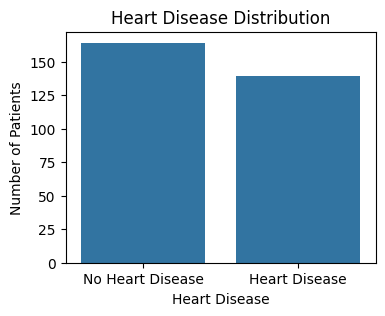

In [ ]:
# Plot target distribution

plt.figure(figsize=(4,3))

sns.countplot(x='target', data=df)

plt.title('Heart Disease Distribution')
plt.xlabel('Heart Disease')
plt.ylabel('Number of Patients')

plt.xticks(
    [0, 1],
    ['No Heart Disease', 'Heart Disease']
)

plt.show()

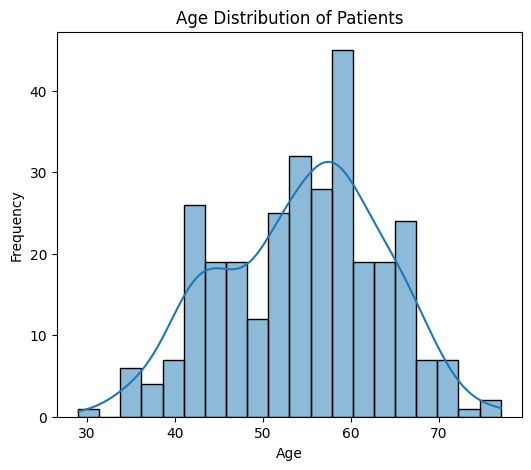

In [ ]:
# Age distribution

plt.figure(figsize=(6,5))

sns.histplot(
    df['age'],
    bins=20,
    kde=True
)

plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

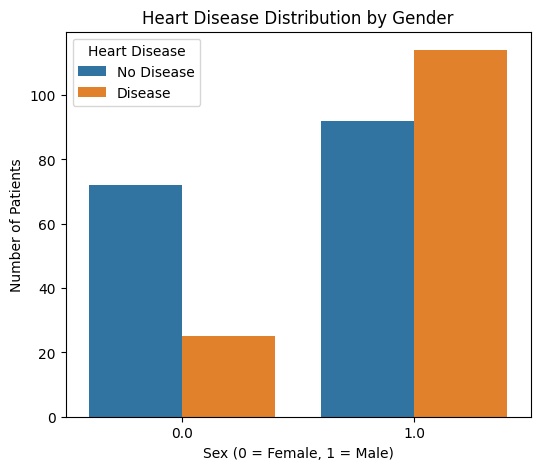

In [ ]:
# Heart disease distribution by sex

plt.figure(figsize=(6,5))

sns.countplot(
    x='sex',
    hue='target',
    data=df
)

plt.title('Heart Disease Distribution by Gender')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Number of Patients')

plt.legend(
    title='Heart Disease',
    labels=['No Disease', 'Disease']
)

plt.show()

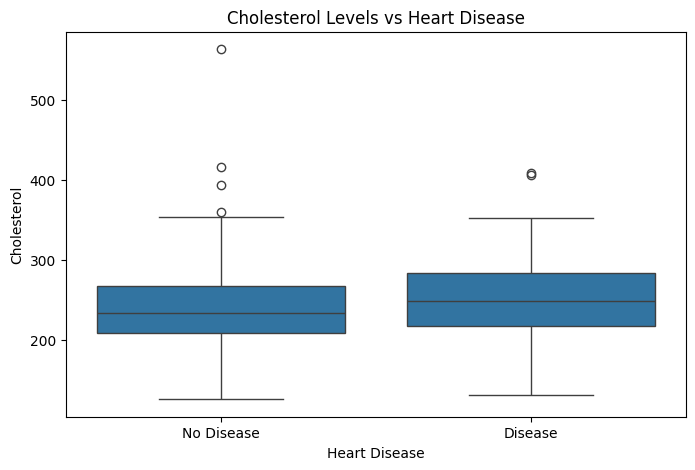

In [ ]:
# Cholesterol distribution

plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='chol',
    data=df
)

plt.title('Cholesterol Levels vs Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Cholesterol')

plt.xticks(
    [0, 1],
    ['No Disease', 'Disease']
)

plt.show()

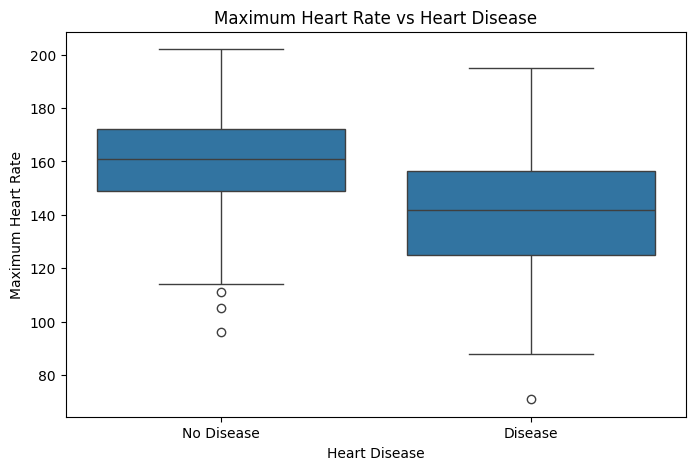

In [ ]:
# Maximum heart rate vs disease

plt.figure(figsize=(8,5))

sns.boxplot(
    x='target',
    y='thalach',
    data=df
)

plt.title('Maximum Heart Rate vs Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Maximum Heart Rate')

plt.xticks(
    [0, 1],
    ['No Disease', 'Disease']
)

plt.show()

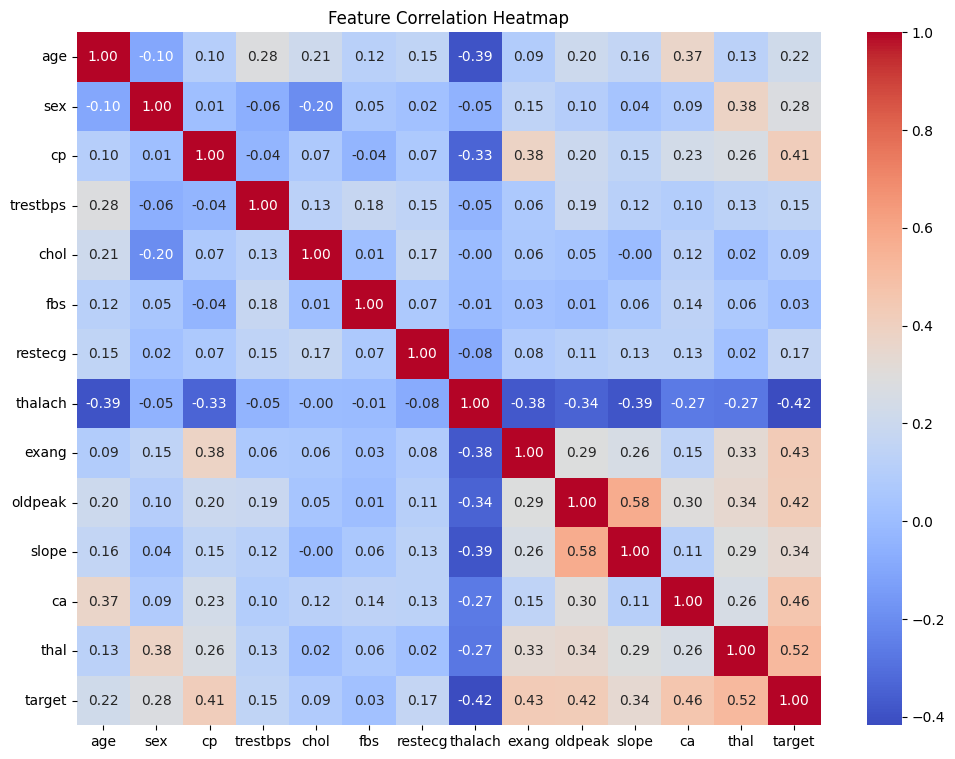

In [ ]:
# Correlation matrix

plt.figure(figsize=(12,9))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Heatmap')

plt.show()

In [ ]:
# ============================================
# OUTLIER ANALYSIS USING IQR
# ============================================

numerical_columns = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        'Feature': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    })

outlier_table = pd.DataFrame(outlier_summary)

display(outlier_table)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,age,48.0,61.0,13.0,28.50,80.50,0
1,trestbps,120.0,140.0,20.0,90.00,170.00,9
2,chol,211.0,275.0,64.0,115.00,371.00,5
3,thalach,133.5,166.0,32.5,84.75,214.75,1
4,oldpeak,0.0,1.6,1.6,-2.40,4.00,5


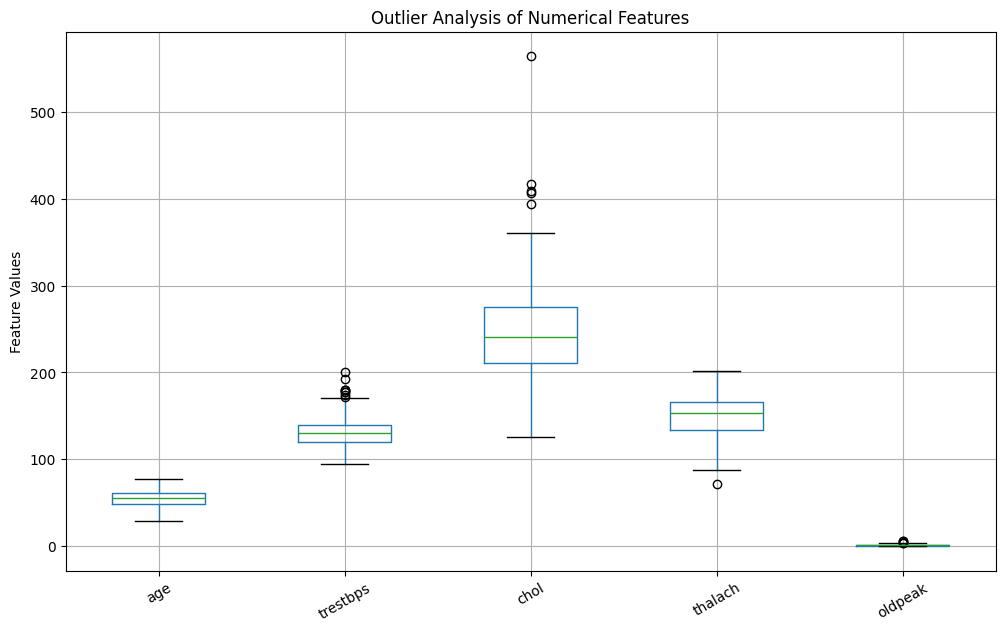

In [ ]:
# ============================================
# BOXPLOTS FOR OUTLIER VISUALIZATION
# ============================================

plt.figure(figsize=(12, 7))

df[numerical_columns].boxplot()

plt.title('Outlier Analysis of Numerical Features')
plt.ylabel('Feature Values')
plt.xticks(rotation=30)

plt.show()

Outliers were identified using the IQR method. They were not automatically removed because extreme clinical observations may represent genuine medical cases. The models were therefore allowed to learn from these observations while numerical features were scaled within the preprocessing pipeline.

In [ ]:
# ============================================
# DOMAIN-INFORMED FEATURE ENGINEERING
# ============================================

df_model = df.copy()

# Age group
df_model['age_group'] = pd.cut(
    df_model['age'],
    bins=[0, 40, 50, 60, 100],
    labels=['Young', 'Middle_Aged', 'Older', 'Senior']
)

# Cholesterol risk category
df_model['cholesterol_level'] = pd.cut(
    df_model['chol'],
    bins=[0, 200, 240, 1000],
    labels=['Desirable', 'Borderline', 'High']
)

# Resting blood pressure category
df_model['bp_category'] = pd.cut(
    df_model['trestbps'],
    bins=[0, 120, 140, 300],
    labels=['Normal', 'Elevated', 'High']
)

# Maximum heart rate relative to age
df_model['heart_rate_ratio'] = (
    df_model['thalach'] /
    (220 - df_model['age'])
)

display(df_model.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,age_group,cholesterol_level,bp_category,heart_rate_ratio
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Senior,Borderline,High,0.955414
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,Senior,High,High,0.705882
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Senior,Borderline,Normal,0.843137
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Young,High,Elevated,1.021858
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Middle_Aged,Borderline,Elevated,0.960894


In [ ]:
# ============================================
# FEATURE ENGINEERING SUMMARY
# ============================================

print("Original number of features:", df.shape[1] - 1)

print("\nNew engineered features:")
print([
    'age_group',
    'cholesterol_level',
    'bp_category',
    'heart_rate_ratio'
])

print("\nNew dataset shape:", df_model.shape)

Original number of features: 13

New engineered features:
['age_group', 'cholesterol_level', 'bp_category', 'heart_rate_ratio']

New dataset shape: (303, 18)


In [ ]:
# ============================================
# SEPARATE FEATURES AND TARGET
# ============================================

X = df_model.drop('target', axis=1)

y = df_model['target']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (303, 17)
Target: (303,)


In [ ]:
# ============================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================

# First split:
# 80% temporary training data
# 20% untouched test data

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split:
# 60% final training
# 20% validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (181, 17)
Validation set: (61, 17)
Test set: (61, 17)


In [ ]:
# ============================================
# FEATURE TYPES
# ============================================

categorical_features = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'ca',
    'thal',
    'age_group',
    'cholesterol_level',
    'bp_category'
]

numerical_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak',
    'heart_rate_ratio'
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'age_group', 'cholesterol_level', 'bp_category']

Numerical features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'heart_rate_ratio']


In [ ]:
# ============================================
# LEAKAGE-SAFE PREPROCESSING PIPELINE
# ============================================

numeric_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'encoder',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            numeric_pipeline,
            numerical_features
        ),
        (
            'categorical',
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Leakage-safe preprocessing pipeline created.")

Leakage-safe preprocessing pipeline created.


## **# BASELINE MODEL**

In [ ]:
# ============================================
# BASELINE: LOGISTIC REGRESSION
# ============================================

baseline_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        (
            'classifier',
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_val_pred = baseline_model.predict(X_val)

baseline_val_prob = baseline_model.predict_proba(
    X_val
)[:, 1]

print("Baseline Logistic Regression trained successfully.")

Baseline Logistic Regression trained successfully.


In [ ]:
# ============================================
# BASELINE VALIDATION RESULTS
# ============================================

baseline_accuracy = accuracy_score(
    y_val,
    baseline_val_pred
)

baseline_precision = precision_score(
    y_val,
    baseline_val_pred
)

baseline_recall = recall_score(
    y_val,
    baseline_val_pred
)

baseline_f1 = f1_score(
    y_val,
    baseline_val_pred
)

baseline_auc = roc_auc_score(
    y_val,
    baseline_val_prob
)

print("BASELINE - LOGISTIC REGRESSION")
print("--------------------------------")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")
print(f"ROC-AUC  : {baseline_auc:.4f}")

BASELINE - LOGISTIC REGRESSION
--------------------------------
Accuracy : 0.8689
Precision: 0.8571
Recall   : 0.8571
F1 Score : 0.8571
ROC-AUC  : 0.9340


In [ ]:
# ============================================
# STRATIFIED CROSS-VALIDATION
# ============================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring_metrics = [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]

print("5-fold Stratified Cross-Validation configured.")

5-fold Stratified Cross-Validation configured.


In [ ]:
# ============================================
# BASELINE CROSS-VALIDATION
# ============================================

cv_results_baseline = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring_metrics
)

print("BASELINE CROSS-VALIDATION")

for metric in scoring_metrics:

    score = cv_results_baseline[
        f'test_{metric}'
    ].mean()

    print(
        f"{metric.upper():10s}: {score:.4f}"
    )

BASELINE CROSS-VALIDATION
ACCURACY  : 0.8012
PRECISION : 0.8034
RECALL    : 0.7588
F1        : 0.7746
ROC_AUC   : 0.8694


In [ ]:
# ============================================
# RANDOM FOREST - BAGGING
# ============================================

rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        (
            'classifier',
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight='balanced'
            )
        )
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [ ]:
# ============================================
# RANDOM FOREST GRID SEARCH
# ============================================

rf_param_grid = {
    'classifier__n_estimators': [
        100,
        200
    ],

    'classifier__max_depth': [
        3,
        5,
        7,
        None
    ],

    'classifier__min_samples_split': [
        2,
        5
    ],

    'classifier__min_samples_leaf': [
        1,
        2
    ]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True
)

rf_grid.fit(
    X_train,
    y_train
)

print("Random Forest tuning completed.")

print("\nBest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(round(rf_grid.best_score_, 4))

Random Forest tuning completed.

Best Parameters:
{'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best CV ROC-AUC:
0.8845


In [ ]:
# ============================================
# RANDOM FOREST VALIDATION
# ============================================

rf_best = rf_grid.best_estimator_

rf_val_pred = rf_best.predict(X_val)

rf_val_prob = rf_best.predict_proba(
    X_val
)[:, 1]

print("RANDOM FOREST - VALIDATION")

print(
    "Accuracy:",
    round(accuracy_score(y_val, rf_val_pred), 4)
)

print(
    "Precision:",
    round(precision_score(y_val, rf_val_pred), 4)
)

print(
    "Recall:",
    round(recall_score(y_val, rf_val_pred), 4)
)

print(
    "F1:",
    round(f1_score(y_val, rf_val_pred), 4)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_val, rf_val_prob), 4)
)

RANDOM FOREST - VALIDATION
Accuracy: 0.8361
Precision: 0.8214
Recall: 0.8214
F1: 0.8214
ROC-AUC: 0.9091


In [ ]:
# ============================================
# INSTALL XGBOOST
# ============================================

!pip install -q xgboost

In [ ]:
from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [ ]:
# ============================================
# XGBOOST - BOOSTING
# ============================================

xgb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        (
            'classifier',
            XGBClassifier(
                eval_metric='logloss',
                random_state=RANDOM_STATE
            )
        )
    ]
)

print("XGBoost pipeline created.")

XGBoost pipeline created.


In [ ]:
# ============================================
# XGBOOST GRID SEARCH
# ============================================

xgb_param_grid = {

    'classifier__n_estimators': [
        100,
        200
    ],

    'classifier__max_depth': [
        2,
        3,
        4
    ],

    'classifier__learning_rate': [
        0.03,
        0.05,
        0.1
    ],

    'classifier__subsample': [
        0.8,
        1.0
    ]
}

xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True
)

xgb_grid.fit(
    X_train,
    y_train
)

print("XGBoost tuning completed.")

print("\nBest Parameters:")
print(xgb_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(round(xgb_grid.best_score_, 4))

XGBoost tuning completed.

Best Parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}

Best CV ROC-AUC:
0.8756


In [ ]:
# ============================================
# XGBOOST VALIDATION
# ============================================

xgb_best = xgb_grid.best_estimator_

xgb_val_pred = xgb_best.predict(X_val)

xgb_val_prob = xgb_best.predict_proba(
    X_val
)[:, 1]

print("XGBOOST - VALIDATION")

print(
    "Accuracy:",
    round(accuracy_score(y_val, xgb_val_pred), 4)
)

print(
    "Precision:",
    round(precision_score(y_val, xgb_val_pred), 4)
)

print(
    "Recall:",
    round(recall_score(y_val, xgb_val_pred), 4)
)

print(
    "F1:",
    round(f1_score(y_val, xgb_val_pred), 4)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_val, xgb_val_prob), 4)
)

XGBOOST - VALIDATION
Accuracy: 0.7869
Precision: 0.7586
Recall: 0.7857
F1: 0.7719
ROC-AUC: 0.921


In [ ]:
# ============================================
# TUNED HETEROGENEOUS SOFT VOTING ENSEMBLE
# ============================================

from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Base heterogeneous models
voting_model = VotingClassifier(
    estimators=[
        (
            'lr',
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        ),

        (
            'rf',
            RandomForestClassifier(
                n_estimators=200,
                max_depth=5,
                random_state=RANDOM_STATE
            )
        ),

        (
            'xgb',
            XGBClassifier(
                n_estimators=150,
                max_depth=3,
                learning_rate=0.05,
                eval_metric='logloss',
                random_state=RANDOM_STATE
            )
        )
    ],
    voting='soft'
)

# Complete preprocessing + voting pipeline
voting_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', voting_model)
    ]
)

# ============================================
# HYPERPARAMETER TUNING
# ============================================

voting_param_grid = {
    'classifier__weights': [
        [1, 1, 1],
        [2, 1, 1],
        [1, 2, 1],
        [1, 1, 2],
        [2, 2, 1],
        [2, 1, 2],
        [1, 2, 2],
        [2, 2, 2]
    ]
}

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

voting_grid = GridSearchCV(
    estimator=voting_pipeline,
    param_grid=voting_param_grid,
    scoring='roc_auc',
    cv=cv_strategy,
    n_jobs=-1,
    refit=True
)

# Train and tune using TRAINING DATA ONLY
voting_grid.fit(X_train, y_train)

# ============================================
# BEST VOTING MODEL
# ============================================

voting_pipeline = voting_grid.best_estimator_

print("✅ Tuned Voting Ensemble created.")
print()
print("Best Voting Weights:")
print(voting_grid.best_params_)

print()
print("Best Cross-Validation ROC-AUC:")
print(round(voting_grid.best_score_, 4))

✅ Tuned Voting Ensemble created.

Best Voting Weights:
{'classifier__weights': [1, 1, 1]}

Best Cross-Validation ROC-AUC:
0.8854


In [ ]:
# ============================================
# TRAIN VOTING ENSEMBLE
# ============================================

voting_pipeline.fit(
    X_train,
    y_train
)

voting_val_pred = voting_pipeline.predict(
    X_val
)

voting_val_prob = voting_pipeline.predict_proba(
    X_val
)[:, 1]

print("Voting Ensemble trained successfully.")

Voting Ensemble trained successfully.


In [ ]:
# ============================================
# VALIDATION MODEL COMPARISON
# ============================================

model_predictions = {

    'Logistic Regression': (
        baseline_val_pred,
        baseline_val_prob
    ),

    'Random Forest': (
        rf_val_pred,
        rf_val_prob
    ),

    'XGBoost': (
        xgb_val_pred,
        xgb_val_prob
    ),

    'Voting Ensemble': (
        voting_val_pred,
        voting_val_prob
    )
}

validation_results = []

for model_name, (pred, prob) in model_predictions.items():

    validation_results.append({

        'Model': model_name,

        'Accuracy': accuracy_score(
            y_val,
            pred
        ),

        'Precision': precision_score(
            y_val,
            pred
        ),

        'Recall': recall_score(
            y_val,
            pred
        ),

        'F1 Score': f1_score(
            y_val,
            pred
        ),

        'ROC-AUC': roc_auc_score(
            y_val,
            prob
        )
    })

validation_results = pd.DataFrame(
    validation_results
)

validation_results = validation_results.sort_values(
    by='ROC-AUC',
    ascending=False
)

display(
    validation_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8689,0.8571,0.8571,0.8571,0.9340
2,XGBoost,0.7869,0.7586,0.7857,0.7719,0.9210
3,Voting Ensemble,0.8197,0.7931,0.8214,0.8070,0.9123
1,Random Forest,0.8361,0.8214,0.8214,0.8214,0.9091


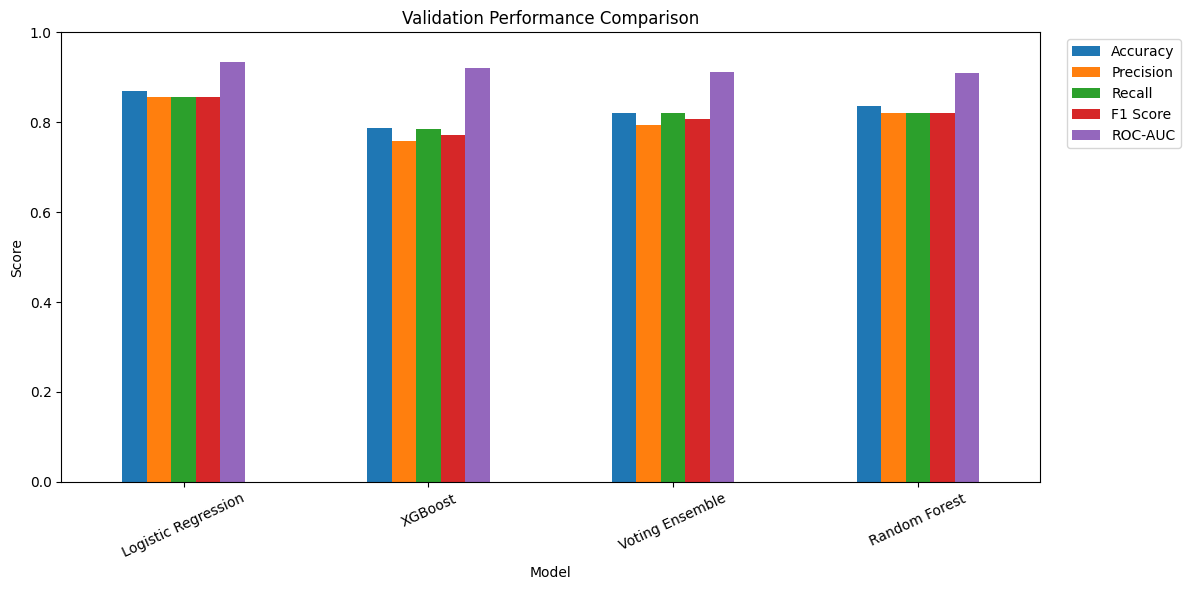

In [ ]:
# ============================================
# MODEL PERFORMANCE VISUALIZATION
# ============================================

validation_results.set_index(
    'Model'
)[
    [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ]
].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Validation Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)

plt.xticks(rotation=25)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

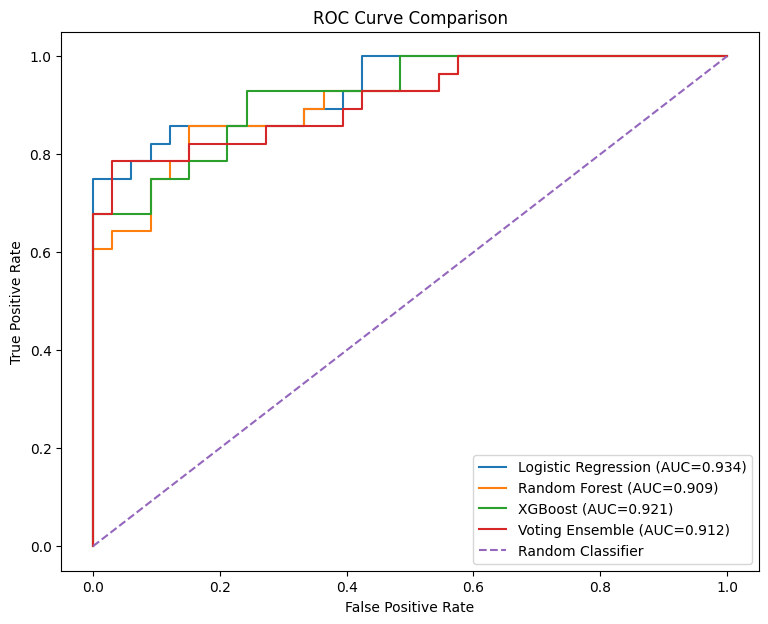

In [ ]:
# ============================================
# ROC CURVE COMPARISON
# ============================================

plt.figure(figsize=(9, 7))

for model_name, (pred, prob) in model_predictions.items():

    fpr, tpr, _ = roc_curve(
        y_val,
        prob
    )

    auc_score = roc_auc_score(
        y_val,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{model_name} (AUC={auc_score:.3f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    '--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

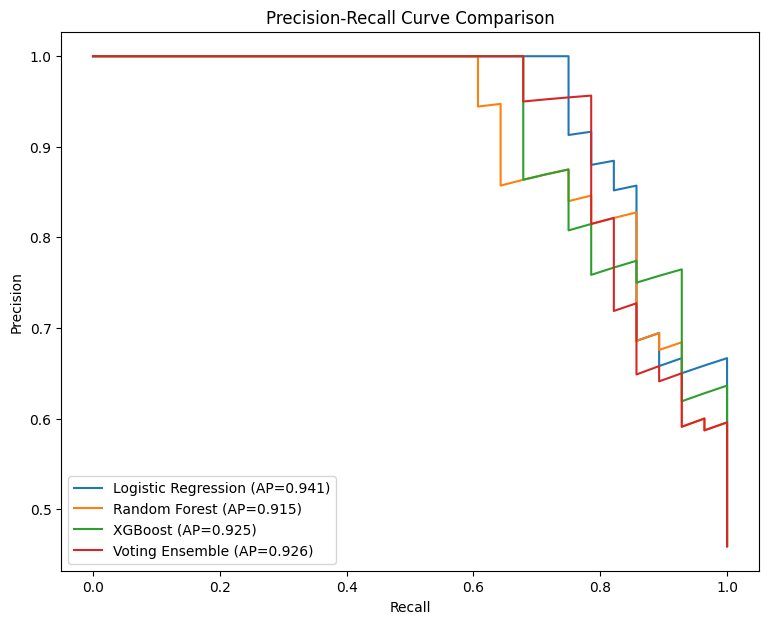

In [ ]:
# ============================================
# PRECISION-RECALL CURVES
# ============================================

plt.figure(figsize=(9, 7))

for model_name, (pred, prob) in model_predictions.items():

    precision, recall, _ = precision_recall_curve(
        y_val,
        prob
    )

    ap = average_precision_score(
        y_val,
        prob
    )

    plt.plot(
        recall,
        precision,
        label=f'{model_name} (AP={ap:.3f})'
    )

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title('Precision-Recall Curve Comparison')

plt.legend()

plt.show()

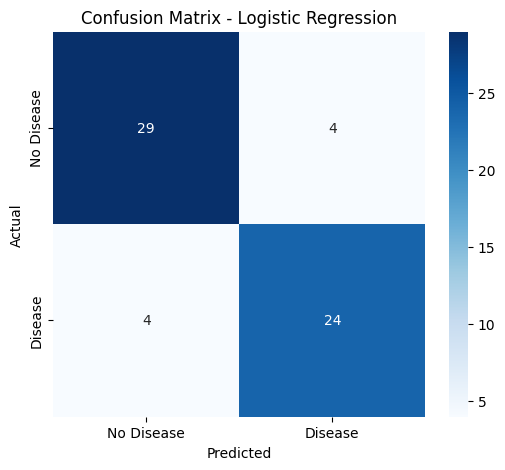

Best validation model: Logistic Regression


In [ ]:
# ============================================
# CONFUSION MATRIX - BEST VALIDATION MODEL
# ============================================

best_model_name = validation_results.iloc[0]['Model']

best_val_pred = model_predictions[
    best_model_name
][0]

cm = confusion_matrix(
    y_val,
    best_val_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',

    xticklabels=[
        'No Disease',
        'Disease'
    ],

    yticklabels=[
        'No Disease',
        'Disease'
    ]
)

plt.title(
    f'Confusion Matrix - {best_model_name}'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

print("Best validation model:", best_model_name)

In [ ]:
# ============================================
# FINAL TEST EVALUATION
# ============================================

final_models = {
    'Logistic Regression': baseline_model,
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
    'Voting Ensemble': voting_pipeline
}

test_results = []

test_predictions = {}

for model_name, model in final_models.items():

    pred = model.predict(X_test)

    prob = model.predict_proba(
        X_test
    )[:, 1]

    test_predictions[model_name] = (
        pred,
        prob
    )

    test_results.append({

        'Model': model_name,

        'Accuracy': accuracy_score(
            y_test,
            pred
        ),

        'Precision': precision_score(
            y_test,
            pred
        ),

        'Recall': recall_score(
            y_test,
            pred
        ),

        'F1 Score': f1_score(
            y_test,
            pred
        ),

        'ROC-AUC': roc_auc_score(
            y_test,
            prob
        )
    })

test_results = pd.DataFrame(
    test_results
)

display(
    test_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8852,0.8387,0.9286,0.8814,0.9632
1,Random Forest,0.8689,0.8125,0.9286,0.8667,0.9416
2,XGBoost,0.8689,0.7941,0.9643,0.8710,0.9621
3,Voting Ensemble,0.8852,0.8182,0.9643,0.8852,0.9502


In [ ]:
# ============================================
# BASELINE VS ENSEMBLE
# ============================================

baseline_test = test_results[
    test_results['Model'] ==
    'Logistic Regression'
].iloc[0]

ensemble_test = test_results[
    test_results['Model'] ==
    'Voting Ensemble'
].iloc[0]

comparison = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],

    'Baseline Logistic Regression': [
        baseline_test['Accuracy'],
        baseline_test['Precision'],
        baseline_test['Recall'],
        baseline_test['F1 Score'],
        baseline_test['ROC-AUC']
    ],

    'Voting Ensemble': [
        ensemble_test['Accuracy'],
        ensemble_test['Precision'],
        ensemble_test['Recall'],
        ensemble_test['F1 Score'],
        ensemble_test['ROC-AUC']
    ]
})

display(
    comparison.round(4)
)

,Metric,Baseline Logistic Regression,Voting Ensemble
0,Accuracy,0.8852,0.8852
1,Precision,0.8387,0.8182
2,Recall,0.9286,0.9643
3,F1 Score,0.8814,0.8852
4,ROC-AUC,0.9632,0.9502


In [ ]:
# ============================================
# SELECT BEST FINAL MODEL USING VALIDATION
# ============================================

# Select the model using VALIDATION ROC-AUC,
# not the untouched test set.

best_final_model_name = validation_results.loc[
    validation_results['ROC-AUC'].idxmax(),
    'Model'
]

best_final_model = final_models[
    best_final_model_name
]

print("Best final model selected using validation performance:")
print(best_final_model_name)

print("\nValidation performance:")

display(
    validation_results[
        validation_results['Model'] ==
        best_final_model_name
    ].round(4)
)

Best final model selected using validation performance:
Logistic Regression

Validation performance:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8689,0.8571,0.8571,0.8571,0.934


In [ ]:
# ============================================
# FINAL CLASSIFICATION REPORT
# ============================================

best_test_pred = test_predictions[
    best_final_model_name
][0]

print(
    classification_report(
        y_test,
        best_test_pred,

        target_names=[
            'No Heart Disease',
            'Heart Disease'
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.93      0.85      0.89        33
   Heart Disease       0.84      0.93      0.88        28

        accuracy                           0.89        61
       macro avg       0.89      0.89      0.89        61
    weighted avg       0.89      0.89      0.89        61



In [ ]:
# ============================================
# INSTALL SHAP
# ============================================

!pip install -q shap

In [ ]:
import shap

print("SHAP imported successfully.")

SHAP imported successfully.


In [ ]:
# ============================================
# PREPARE RANDOM FOREST FOR SHAP
# ============================================

rf_preprocessor = rf_best.named_steps[
    'preprocessor'
]

rf_classifier = rf_best.named_steps[
    'classifier'
]

X_train_processed = rf_preprocessor.transform(
    X_train
)

X_test_processed = rf_preprocessor.transform(
    X_test
)

feature_names_shap = (
    rf_preprocessor
    .get_feature_names_out()
)

print(
    "Processed feature count:",
    len(feature_names_shap)
)

Processed feature count: 39


In [ ]:
# ============================================
# SHAP TREE EXPLAINER
# ============================================

explainer = shap.TreeExplainer(
    rf_classifier
)

shap_values = explainer.shap_values(
    X_test_processed
)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


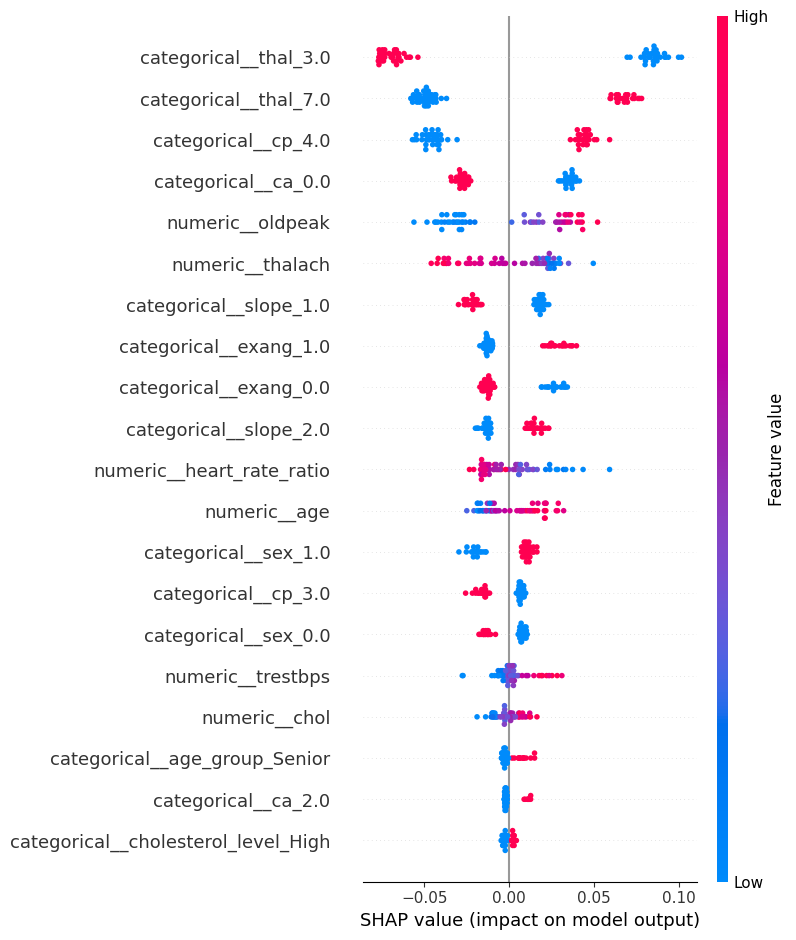

In [ ]:
# ============================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================

shap.summary_plot(
    shap_values[:, :, 1],
    X_test_processed,
    feature_names=feature_names_shap,
    show=True
)

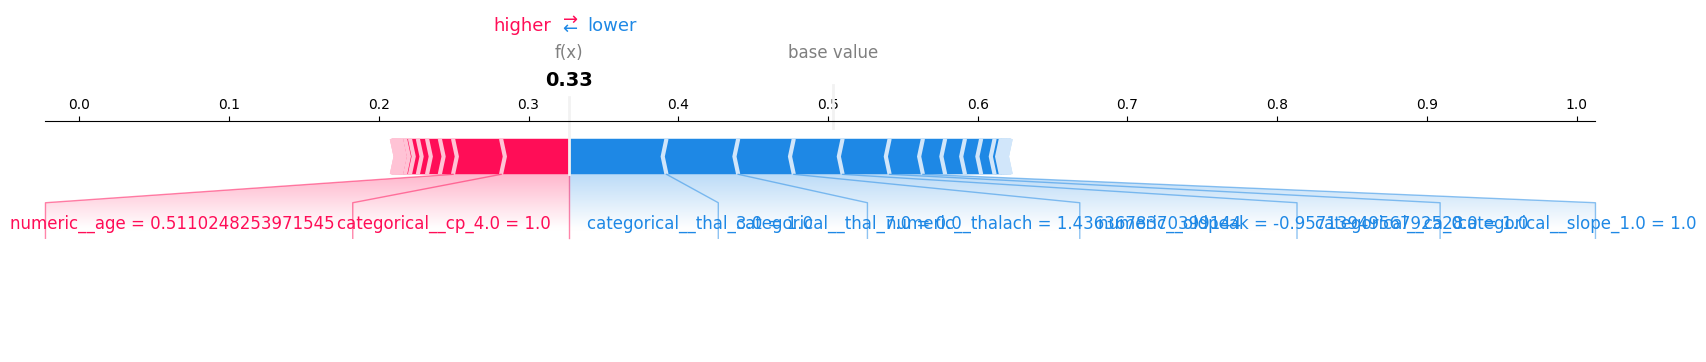

<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================
# INDIVIDUAL PATIENT SHAP EXPLANATION
# ============================================

import os
import matplotlib.pyplot as plt

# Make sure the folder exists
os.makedirs(f"{PROJECT}/explainability", exist_ok=True)

patient_index = 0

shap.force_plot(
    explainer.expected_value[1],
    shap_values[patient_index, :, 1],
    X_test_processed[patient_index],
    feature_names=feature_names_shap,
    matplotlib=True
)

plt.tight_layout()

# SAVE BEFORE SHOW
plt.savefig(
    f"{PROJECT}/explainability/shap_individual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



In [ ]:
# ============================================
# SHAP FEATURE IMPORTANCE TABLE
# ============================================

mean_abs_shap = np.abs(
    shap_values[:, :, 1]
).mean(axis=0)

shap_importance = pd.DataFrame({

    'Feature': feature_names_shap,

    'Mean Absolute SHAP Value':
        mean_abs_shap

})

shap_importance = shap_importance.sort_values(
    by='Mean Absolute SHAP Value',
    ascending=False
)

display(
    shap_importance.head(15)
)

,Feature,Mean Absolute SHAP Value
26,categorical__thal_3.0,0.076741
28,categorical__thal_7.0,0.055950
11,categorical__cp_4.0,0.045212
22,categorical__ca_0.0,0.031365
4,numeric__oldpeak,0.031023
3,numeric__thalach,0.022830
19,categorical__slope_1.0,0.019788
18,categorical__exang_1.0,0.018205
17,categorical__exang_0.0,0.017483
20,categorical__slope_2.0,0.014535


In [ ]:
# ============================================
# ERROR ANALYSIS
# ============================================

best_test_pred = test_predictions[
    best_final_model_name
][0]

error_analysis = X_test.copy()

error_analysis['Actual'] = y_test.values

error_analysis['Predicted'] = best_test_pred

error_analysis['Correct'] = (
    error_analysis['Actual'] ==
    error_analysis['Predicted']
)

errors = error_analysis[
    error_analysis['Correct'] == False
]

print(
    "Total test samples:",
    len(error_analysis)
)

print(
    "Incorrect predictions:",
    len(errors)
)

display(errors)

Total test samples: 61
Incorrect predictions: 7


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,age_group,cholesterol_level,bp_category,heart_rate_ratio,Actual,Predicted,Correct
271,66.0,1.0,4.0,160.0,228.0,0.0,2.0,138.0,0.0,2.3,1.0,0.0,6.0,Senior,Borderline,High,0.896104,0,1,False
196,69.0,1.0,1.0,160.0,234.0,1.0,2.0,131.0,0.0,0.1,2.0,1.0,3.0,Senior,Borderline,High,0.867550,0,1,False
33,59.0,1.0,4.0,135.0,234.0,0.0,0.0,161.0,0.0,0.5,2.0,0.0,7.0,Older,Borderline,Elevated,1.000000,0,1,False
292,44.0,1.0,4.0,120.0,169.0,0.0,0.0,144.0,1.0,2.8,3.0,0.0,6.0,Middle_Aged,Desirable,Normal,0.818182,1,0,False
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,0.0,7.0,Older,Borderline,Elevated,0.888889,0,1,False
66,60.0,1.0,3.0,140.0,185.0,0.0,2.0,155.0,0.0,3.0,2.0,0.0,3.0,Older,Desirable,Elevated,0.968750,1,0,False
92,62.0,1.0,3.0,130.0,231.0,0.0,0.0,146.0,0.0,1.8,2.0,3.0,7.0,Senior,Borderline,Elevated,0.924051,0,1,False


In [ ]:
# ============================================
# FALSE POSITIVE AND FALSE NEGATIVE ANALYSIS
# ============================================

false_positives = error_analysis[
    (error_analysis['Actual'] == 0) &
    (error_analysis['Predicted'] == 1)
]

false_negatives = error_analysis[
    (error_analysis['Actual'] == 1) &
    (error_analysis['Predicted'] == 0)
]

print(
    "False Positives:",
    len(false_positives)
)

print(
    "False Negatives:",
    len(false_negatives)
)

False Positives: 5
False Negatives: 2


In [ ]:
# ============================================
# SIMPLE GROUP PERFORMANCE CHECK BY SEX
# ============================================

fairness_data = X_test.copy()

fairness_data['Actual'] = y_test.values

fairness_data['Predicted'] = best_test_pred

for sex_value in sorted(
    fairness_data['sex'].unique()
):

    group = fairness_data[
        fairness_data['sex'] == sex_value
    ]

    if len(group) > 0:

        group_recall = recall_score(
            group['Actual'],
            group['Predicted'],
            zero_division=0
        )

        group_precision = precision_score(
            group['Actual'],
            group['Predicted'],
            zero_division=0
        )

        print(
            f"Sex = {int(sex_value)}"
        )

        print(
            "Samples:",
            len(group)
        )

        print(
            "Recall:",
            round(group_recall, 4)
        )

        print(
            "Precision:",
            round(group_precision, 4)
        )

        print()

Sex = 0
Samples: 20
Recall: 1.0
Precision: 1.0

Sex = 1
Samples: 41
Recall: 0.9048
Precision: 0.7917



In [ ]:
# ============================================
# SYNTHETIC PATIENT FOR LIVE DEMO
# ============================================

synthetic_patient = pd.DataFrame({

    'age': [58],

    'sex': [1],

    'cp': [4],

    'trestbps': [145],

    'chol': [270],

    'fbs': [0],

    'restecg': [1],

    'thalach': [135],

    'exang': [1],

    'oldpeak': [1.8],

    'slope': [2],

    'ca': [1],

    'thal': [3],

    'age_group': pd.Categorical(
        ['Older'],
        categories=[
            'Young',
            'Middle_Aged',
            'Older',
            'Senior'
        ]
    ),

    'cholesterol_level': pd.Categorical(
        ['High'],
        categories=[
            'Desirable',
            'Borderline',
            'High'
        ]
    ),

    'bp_category': pd.Categorical(
        ['High'],
        categories=[
            'Normal',
            'Elevated',
            'High'
        ]
    ),

    'heart_rate_ratio': [
        135 / (220 - 58)
    ]
})

display(synthetic_patient)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,age_group,cholesterol_level,bp_category,heart_rate_ratio
0,58,1,4,145,270,0,1,135,1,1.8,2,1,3,Older,High,High,0.833333


In [ ]:
# ============================================
# LIVE HEART DISEASE RISK PREDICTION
# ============================================

prediction = best_final_model.predict(
    synthetic_patient
)[0]

probability = best_final_model.predict_proba(
    synthetic_patient
)[0, 1]

print("=" * 50)

print("HEART DISEASE RISK PREDICTION")

print("=" * 50)

if prediction == 1:

    print(
        "Prediction: Higher predicted risk"
    )

else:

    print(
        "Prediction: Lower predicted risk"
    )

print(
    f"Predicted probability: {probability * 100:.2f}%"
)

print("=" * 50)

print(
    "This is an ML prediction for educational use,"
)

print(
    "not a medical diagnosis."
)

HEART DISEASE RISK PREDICTION
Prediction: Higher predicted risk
Predicted probability: 91.65%
This is an ML prediction for educational use,
not a medical diagnosis.


In [ ]:
# ============================================
# SAVE BEST MODEL
# ============================================

joblib.dump(
    best_final_model,
    'heart_disease_best_model.pkl'
)

print(
    "Best model saved as:"
)

print(
    "heart_disease_best_model.pkl"
)

Best model saved as:
heart_disease_best_model.pkl


In [ ]:
# ============================================
# SAVE RESULTS
# ============================================

test_results.to_csv(
    'heart_disease_model_comparison.csv',
    index=False
)

validation_results.to_csv(
    'heart_disease_validation_results.csv',
    index=False
)

shap_importance.to_csv(
    'heart_disease_shap_importance.csv',
    index=False
)

print("All result files saved successfully.")

All result files saved successfully.
